In [1]:
# ==========================================
# Project 8
# Import Libraries
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# ==========================================
# Step 2 - Load MNIST Dataset
# ==========================================

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset Loaded Successfully!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Loaded Successfully!


In [3]:
# ==========================================
# Check Dataset Shape
# ==========================================

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


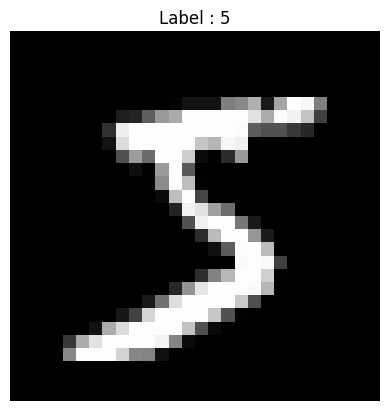

In [4]:
# ==========================================
# Display First Image
# ==========================================

plt.imshow(X_train[0], cmap="gray")

plt.title(f"Label : {y_train[0]}")

plt.axis("off")

plt.show()

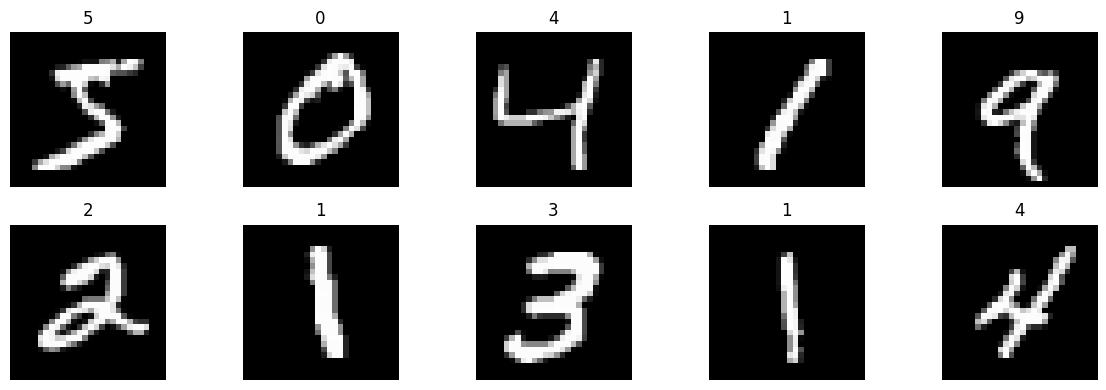

In [6]:
# ==========================================
# Show First 10 Images
# ==========================================

plt.figure(figsize=(12,4))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(y_train[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [7]:
# ==========================================
# Normalize Images
# ==========================================

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Images Normalized Successfully!")

Images Normalized Successfully!


In [8]:
print("Minimum Value :", X_train.min())
print("Maximum Value :", X_train.max())

Minimum Value : 0.0
Maximum Value : 1.0


In [9]:
# ==========================================
# Step 4.1 - Build Neural Network
# ==========================================

model = Sequential([

    Flatten(input_shape=(28, 28)),

    Dense(128, activation="relu"),

    Dense(64, activation="relu"),

    Dense(10, activation="softmax")

])

print("Neural Network Created Successfully!")

Neural Network Created Successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# ==========================================
# Compile Model
# ==========================================

model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [11]:
# ==========================================
# Model Summary
# ==========================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ==========================================
# Step 5.1 - Train Neural Network
# ==========================================

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9211 - loss: 0.2652 - val_accuracy: 0.9597 - val_loss: 0.1367
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9669 - loss: 0.1090 - val_accuracy: 0.9658 - val_loss: 0.1195
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9765 - loss: 0.0757 - val_accuracy: 0.9681 - val_loss: 0.1026
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9825 - loss: 0.0559 - val_accuracy: 0.9732 - val_loss: 0.0967
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9861 - loss: 0.0442 - val_accuracy: 0.9709 - val_loss: 0.1044
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9891 - loss: 0.0335 - val_accuracy: 0.9681 - val_loss: 0.1133
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9910 - loss: 0.0273 - val_accuracy: 0.9715 - val_loss: 0.1078
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9920 - loss: 0.0226 - 

In [30]:
# ==========================================
# Evaluate Keras Model
# ==========================================

test_loss_keras, test_accuracy_keras = model.evaluate(X_test, y_test)

print("Keras Test Accuracy:", test_accuracy_keras)
print("Keras Test Loss:", test_loss_keras)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9733 - loss: 0.1112
Keras Test Accuracy: 0.9732999801635742
Keras Test Loss: 0.11122143268585205


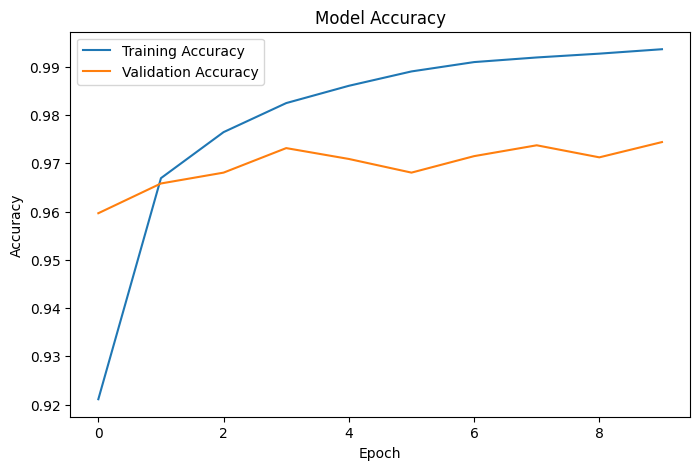

In [31]:
# ==========================================
# Accuracy Graph
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

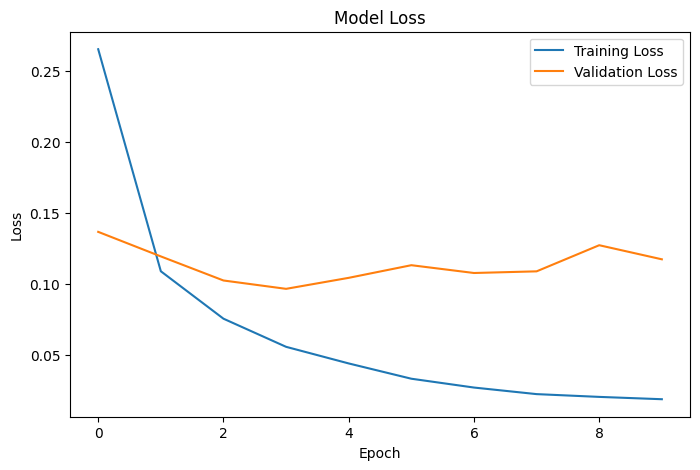

In [32]:
# ==========================================
# Loss Graph
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [33]:
# ==========================================
# Predict Test Images
# ==========================================

predictions = model.predict(X_test)

predicted_labels = predictions.argmax(axis=1)

print(predicted_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 0 4 1 4 9 5 9]


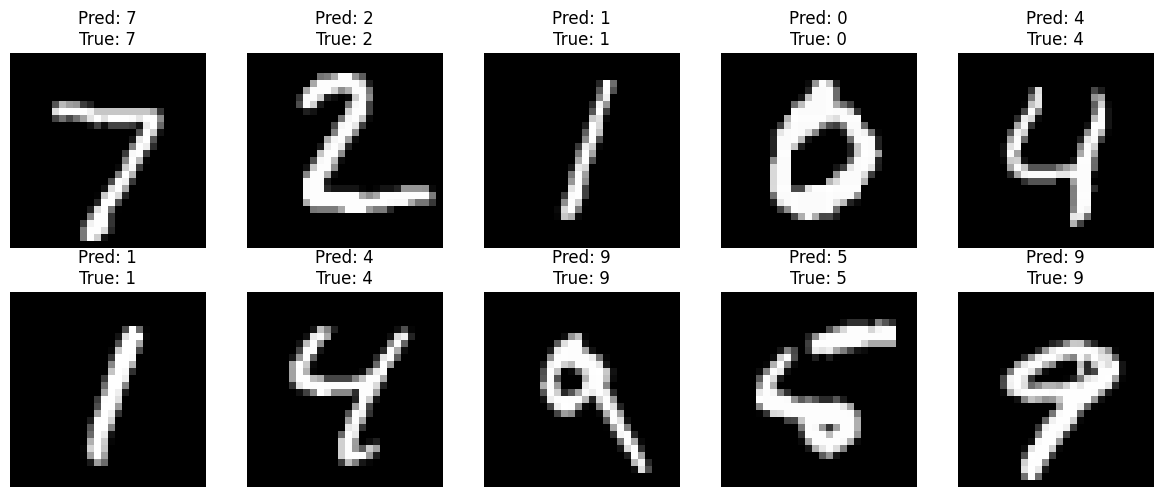

In [34]:
# ==========================================
# Show First 10 Predictions
# ==========================================

plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i], cmap="gray")

    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {y_test[i]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
# ==========================================
# Wrong Predictions
# ==========================================

wrong = []

for i in range(len(y_test)):
    if predicted_labels[i] != y_test[i]:
        wrong.append(i)

print("Total Wrong Predictions:", len(wrong))

Total Wrong Predictions: 267


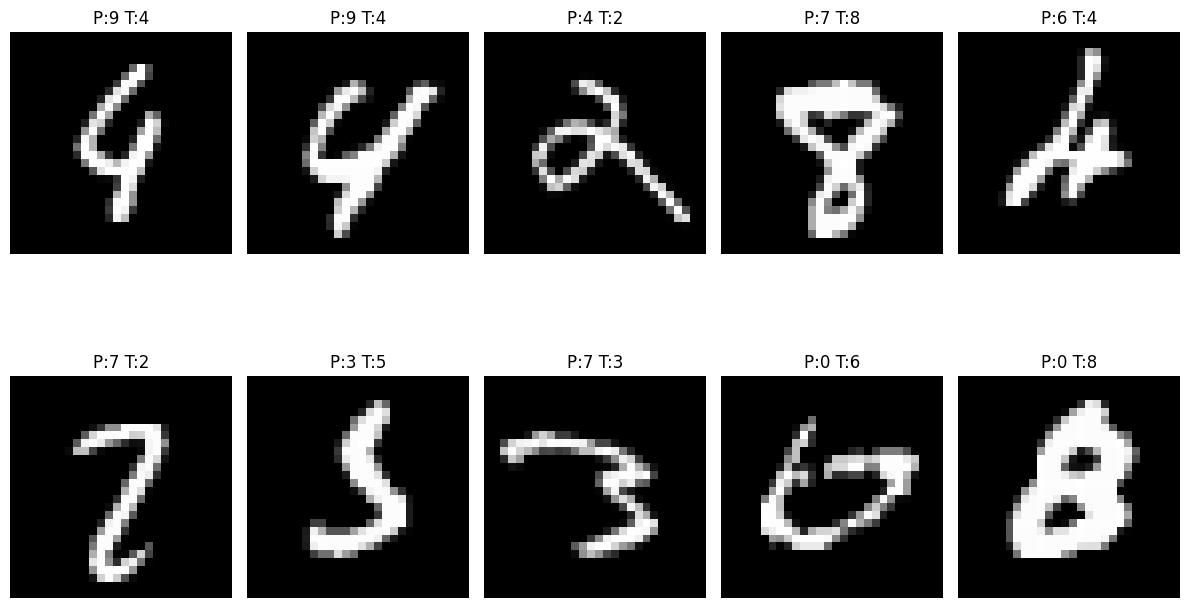

In [36]:
plt.figure(figsize=(12,8))

for i in range(10):

    index = wrong[i]

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[index], cmap="gray")

    plt.title(f"P:{predicted_labels[index]} T:{y_test[index]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
# ==========================================
# Convert NumPy Arrays to PyTorch Tensors
# ==========================================

import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Conversion Successful!")

Conversion Successful!


In [38]:

# ==========================================
# Create DataLoader
# ==========================================

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("DataLoader Created!")




DataLoader Created!


In [39]:
# ==========================================
# PyTorch Neural Network
# ==========================================

import torch.nn as nn

class NeuralNetwork(nn.Module):

    def __init__(self):

        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(

            nn.Linear(28*28,128),

            nn.ReLU(),

            nn.Linear(128,64),

            nn.ReLU(),

            nn.Linear(64,10)

        )

    def forward(self,x):

        x = self.flatten(x)

        return self.network(x)

model_torch = NeuralNetwork()

print(model_torch)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [40]:
# ==========================================
# Loss and Optimizer
# ==========================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_torch.parameters(),
    lr=0.001
)

print("Loss Function and Optimizer Ready!")

Loss Function and Optimizer Ready!


In [41]:
# ==========================================
# Training Loop
# ==========================================

epochs = 10

train_accuracy = []

for epoch in range(epochs):

    correct = 0
    total = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model_torch(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        _, predicted = torch.max(outputs.data,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = correct/total

    train_accuracy.append(accuracy)

    print(f"Epoch {epoch+1}/{epochs} Accuracy: {accuracy:.4f}")

Epoch 1/10 Accuracy: 0.9175
Epoch 2/10 Accuracy: 0.9649
Epoch 3/10 Accuracy: 0.9750
Epoch 4/10 Accuracy: 0.9811
Epoch 5/10 Accuracy: 0.9844
Epoch 6/10 Accuracy: 0.9877
Epoch 7/10 Accuracy: 0.9896
Epoch 8/10 Accuracy: 0.9911
Epoch 9/10 Accuracy: 0.9927
Epoch 10/10 Accuracy: 0.9931


In [42]:

# ==========================================
# Evaluate PyTorch Model
# ==========================================

model_torch.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model_torch(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy_pytorch = correct / total

print(f"PyTorch Test Accuracy: {test_accuracy_pytorch:.4f}")

PyTorch Test Accuracy: 0.9790


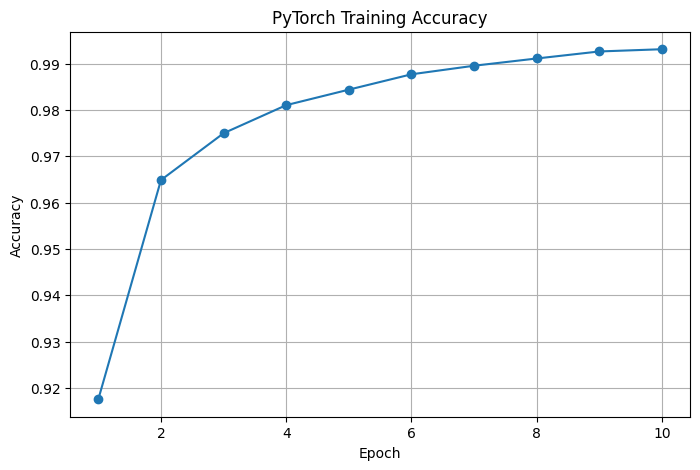

In [43]:
# ==========================================
# PyTorch Accuracy Graph
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1, len(train_accuracy)+1),
         train_accuracy,
         marker="o")

plt.title("PyTorch Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [44]:
# ==========================================
# Compare Frameworks
# ==========================================

import pandas as pd

comparison = pd.DataFrame({

    "Framework":[
        "TensorFlow / Keras",
        "PyTorch"
    ],

    "Test Accuracy":[
        test_accuracy_keras,
        test_accuracy_pytorch
    ]

})

print(comparison)

            Framework  Test Accuracy
0  TensorFlow / Keras         0.9733
1             PyTorch         0.9790


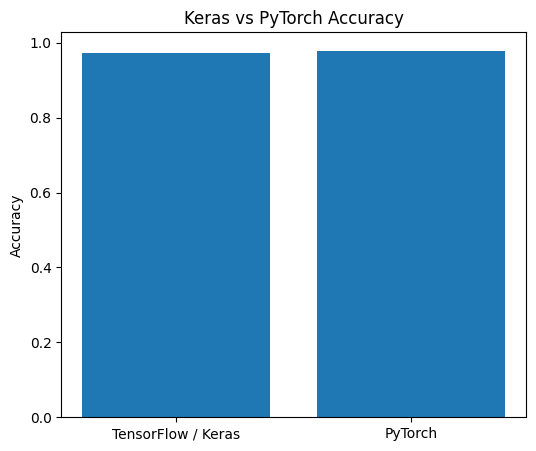

In [45]:
# ==========================================
# Compare Accuracy
# ==========================================

plt.figure(figsize=(6,5))

plt.bar(
    comparison["Framework"],
    comparison["Test Accuracy"]
)

plt.title("Keras vs PyTorch Accuracy")

plt.ylabel("Accuracy")

plt.show()

In [46]:
# ==========================================
# Wrong Predictions
# ==========================================

wrong_images = []
wrong_preds = []
wrong_labels = []

model_torch.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model_torch(images)

        _, predicted = torch.max(outputs,1)

        for i in range(len(labels)):

            if predicted[i] != labels[i]:

                wrong_images.append(images[i])

                wrong_preds.append(predicted[i].item())

                wrong_labels.append(labels[i].item())

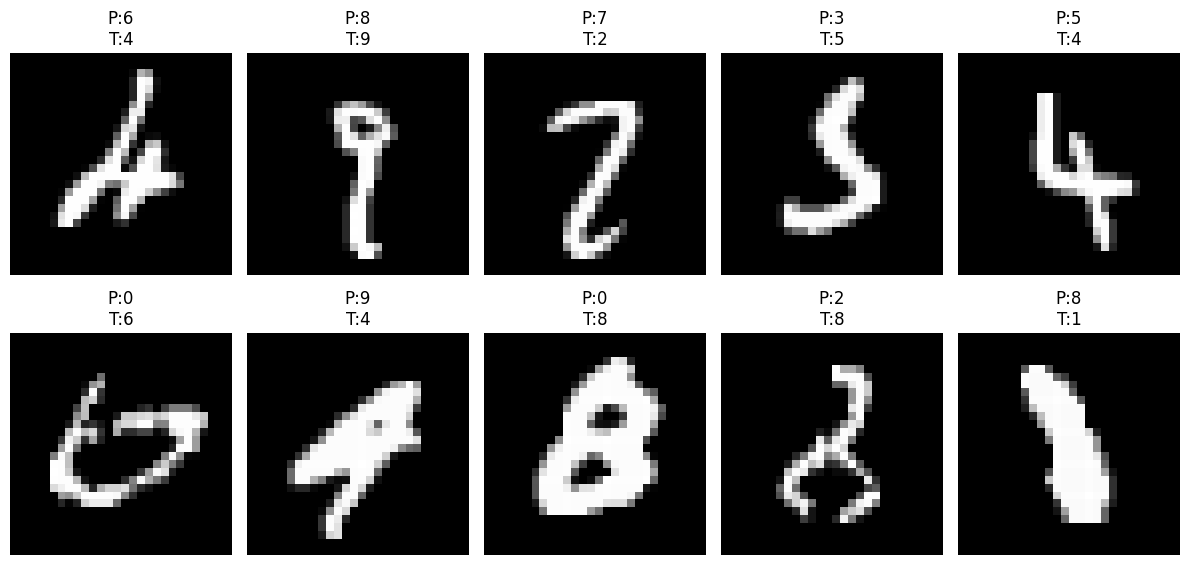

In [47]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(wrong_images[i].numpy(),
               cmap="gray")

    plt.title(
        f"P:{wrong_preds[i]}\nT:{wrong_labels[i]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()